# Field deposition

This quick tutorial shows a minimal 3D deposition workflow using
`PointCloud.add_field` and `deposit_to_grid`. It then demonstrates how to
compute per‑particle gradients (at particle positions), add them as fields,
and deposit those gradient fields to the same grid. Note: depositing
per‑particle gradients is not the same as taking finite differences of a
scalar field after deposition — both are legitimate but different
operations (see final note).

In [9]:
# global setup
import numpy as np
import matplotlib.pyplot as plt
import smudgy as sm

plt.style.use("../mpl_stylefile")
%matplotlib inline
%config InlineBackend.figure_format='retina'

## 1) Setup and deposit a scalar field (3D)

[smudgy] Initialized 3d PointCloud with 5000 particles in periodic box of size=[1. 1. 1.]
[smudgy] Building kd-tree from particle positions
[smudgy] Computing smoothing lengths from 32 neighbors
[smudgy] Using c++ backend for isotropic deposition (isotropic_3d)


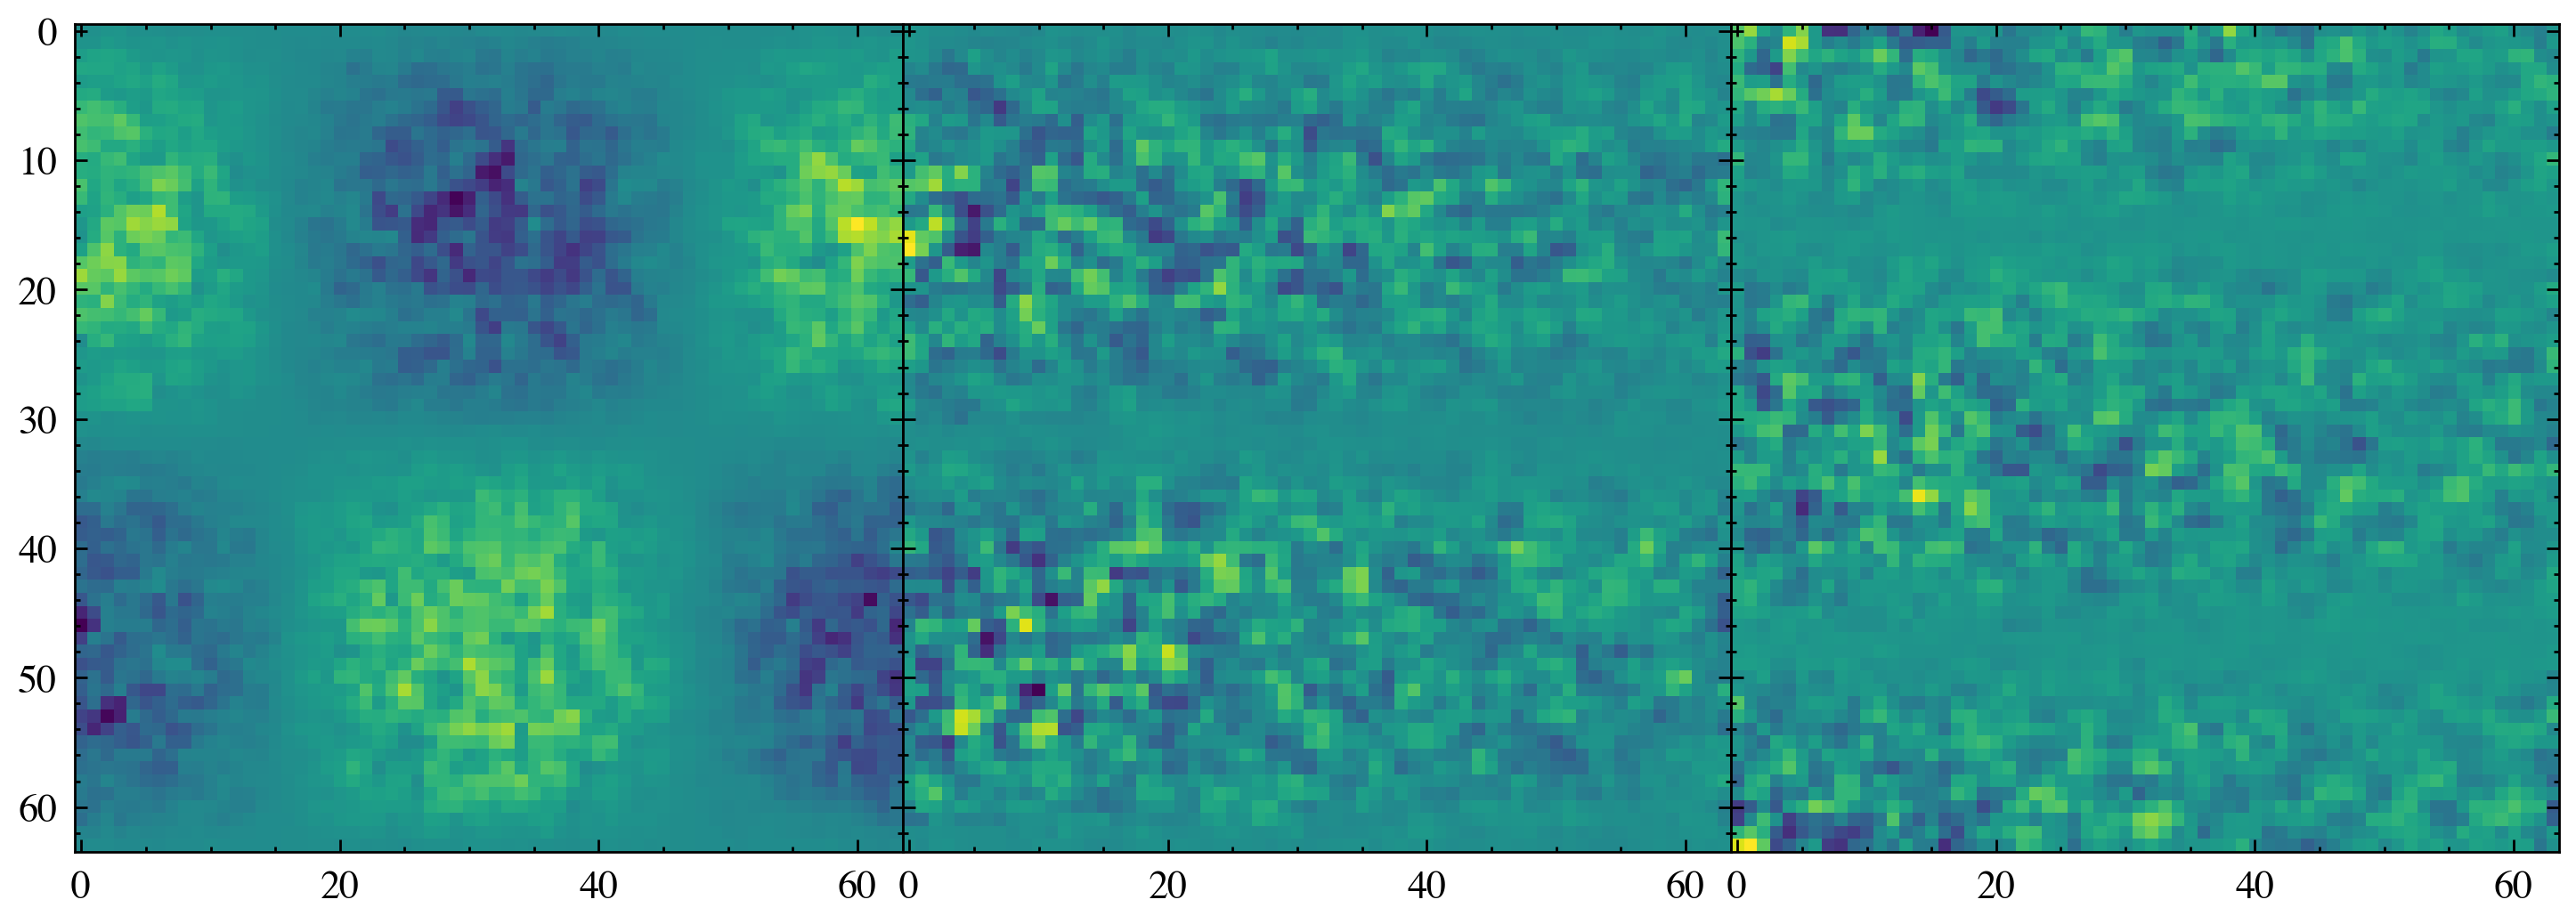

In [14]:
# --- sample 3D particles and a scalar field ---
boxsize = 1.0
N = 5000
pos = np.random.uniform(0.0, boxsize, size=(N, 3))
weights = np.ones(N)

# scalar field on particles (example smooth function)
vals = np.sin(2*np.pi*pos[:,0]) * np.cos(2*np.pi*pos[:,1]) * np.exp(-pos[:,2])

# --- create and configure PointCloud ---
pc = sm.PointCloud(pos, weights, boxsize=boxsize)
pc.global_setup(kernel_name='cubic_spline', structure='isotropic', num_neighbors=32)
pc.compute_smoothing()

# attach the field to the PointCloud (convenience for later calls)
pc.add_fields('temperature', vals)

# --- deposit to a 3D grid ---
nx = 64
grid_flat, weights_flat = pc.deposit_to_grid(fields='temperature', averaged=True, gridnums=(nx,nx,nx), return_weights=True)

# reshape the flattened result to (nx, nx, nx)
grid_scalar = grid_flat

fig, ax = plt.subplots(1, 3, figsize=(9, 6), sharex=True, sharey=True)
ax[0].imshow(grid_scalar.sum(axis=(2, -1)))     # "xy" projection
ax[1].imshow(grid_scalar.sum(axis=(1, -1)))     # "xz" projection
ax[2].imshow(grid_scalar.sum(axis=(0, -1)))     # "yz" projection

plt.show()

## 2) Compute gradients at particle positions and deposit them

Compute per‑particle gradients using the interpolation routines, add them
with `add_field`, and deposit the vector field to the same grid.

In [ ]:

# compute gradients at particle positions (returns shape (N, 1, 3) for a single scalar)
grads = pc.interpolate_gradient_fields(fields=vals, query_positions=pc.positions)  # shape (N, 1, 3)
grads_vec = grads[:, 0, :]  # (N, 3)

# attach as a multi-component field and deposit
pc.add_fields('temperature_grad', grads_vec)
grid_grads_flat = pc.deposit_to_grid(fields='temperature_grad', averaged=True, gridnums=(nx,nx,nx))

# reshape to (nx, nx, nx, 3)
grid_grads = grid_grads_flat.reshape((nx, nx, nx, 3))

# quick derived quantity: gradient magnitude on the grid
grad_mag_from_particles = np.linalg.norm(grid_grads, axis=-1)
```

### Quick note on differences

- Depositing per‑particle gradients preserves the local gradient estimates
	computed at particle scales and then averages them into cells.
- Computing the gradient of the deposited scalar field (e.g. via
	finite‑differences on `grid_scalar`) produces a different result because of
	cell averaging and the finite‑difference operator.

In short: "deposit(grad f)" != "grad(deposit f)". Use the first when you
trust particle‑scale gradient estimates and want those carried to the grid;
use the second when you prefer derivatives computed on the (possibly
smoothed) grid representation.


## 3) Projected depositions

In [15]:
# --- sample 3D particles and a scalar field ---
boxsize = 1.0
N = 5000
pos = np.random.uniform(0.0, boxsize, size=(N, 3))
weights = np.ones(N)

# scalar field on particles (example smooth function)
vals = np.sin(2*np.pi*pos[:,0]) * np.cos(2*np.pi*pos[:,1]) * np.exp(-pos[:,2])

# --- create and configure PointCloud ---
pc = sm.PointCloud(pos, weights, boxsize=boxsize)
pc.global_setup(kernel_name='cubic_spline', structure='anisotropic', num_neighbors=32)
pc.compute_smoothing()

# attach the field to the PointCloud (convenience for later calls)
pc.add_fields('temperature', vals)

[smudgy] Initialized 3d PointCloud with 5000 particles in periodic box of size=[1. 1. 1.]
[smudgy] Building kd-tree from particle positions
[smudgy] Computing smoothing tensors from 32 neighbors


In [16]:
# project to 2D grid
nx = 128
grid_flat, weights_flat = pc.deposit_to_grid(fields='temperature', averaged=True, gridnums=nx, return_weights=True,
                                             plane_projection='xy')
print(grid_flat.shape)  # (nx, nx)

ValueError: operands could not be broadcast together with shapes (5000,2) (3,) 

In [ ]:

fig, ax = plt.subplots(1, 3, figsize=(9, 6), sharex=True, sharey=True)
ax[0].imshow(grid_scalar.sum(axis=(2, -1)))     # "xy" projection
ax[1].imshow(grid_scalar.sum(axis=(1, -1)))     # "xz" projection
ax[2].imshow(grid_scalar.sum(axis=(0, -1)))     # "yz" projection

plt.show()

## Final remark

Both approaches are supported by `smudgy` and can be used together. For very
large grids or production runs prefer lower memory usage (smaller `nx`) or
the C++ backend (`use_openmp=True`) to speed up deposition.